In [ ]:
%pip install -r requirements.txt

In [62]:
#実験１

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/outlier_deal_for_nan_exp1.csv"
df = pd.read_csv(path)

In [55]:
#実験２

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/outlier_deal_for_nan_exp2.csv"
df = pd.read_csv(path)

In [29]:
df.shape

(8800, 14)

In [30]:
df

,Unnamed: 0,responseId,frame_block,ref_subblock,Message Group,Page Submit_fc,frame_choice,Page Submit_wl,Water Level,Page Submit_al,Alertness Level,Affect Level,is_outlier,outlier_columns
0,0,R_4HKyBG3cpnZbBOp,0,0,positive,4.216,1.0,3.712,44.0,7.795,61.0,72.0,False,NaN
1,1,R_4HKyBG3cpnZbBOp,0,1,positive,4.216,1.0,3.065,153.0,7.336,57.0,62.0,False,NaN
2,2,R_4HKyBG3cpnZbBOp,0,2,positive,4.216,1.0,3.095,468.0,6.114,60.0,72.0,False,NaN
3,3,R_4HKyBG3cpnZbBOp,0,3,positive,4.216,1.0,3.267,371.0,7.372,40.0,80.0,False,NaN
4,4,R_4HKyBG3cpnZbBOp,0,4,positive,4.216,1.0,7.364,214.0,8.872,38.0,70.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,8795,R_9DYMWHvc9AIQcr7,19,0,neutral,4.247,1.0,6.345,50.0,11.588,60.0,60.0,False,NaN
8796,8796,R_9DYMWHvc9AIQcr7,19,1,neutral,4.247,1.0,10.196,200.0,15.229,40.0,70.0,False,NaN
8797,8797,R_9DYMWHvc9AIQcr7,19,2,neutral,4.247,1.0,7.341,450.0,10.396,60.0,70.0,False,NaN
8798,8798,R_9DYMWHvc9AIQcr7,19,3,neutral,4.247,1.0,6.812,352.0,10.335,50.0,61.0,False,NaN


#### フレーム選択率、数

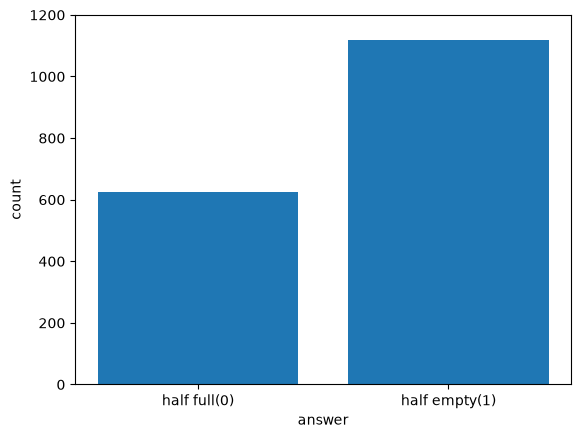

In [63]:
block_keys = ["responseId", "frame_block"]

# NaN の行を先に除く
valid = df.dropna(subset=["frame_choice", "Message Group"]).copy()

# ブロックごとの有効行数で割った重み(1ブロック分の合計が1になる)
valid["w"] = 1 / valid.groupby(block_keys)["frame_choice"].transform("count")

counts = pd.crosstab(
    valid["Message Group"],
    valid["frame_choice"],
    values=valid["w"],
    aggfunc="sum",
).fillna(0)

total = counts.reindex(columns=[0, 1], fill_value=0).sum()

plt.ylim(0,1200)
plt.bar(["half full(0)", "half empty(1)"], total)
plt.xlabel("answer")
plt.ylabel("count")
plt.show()

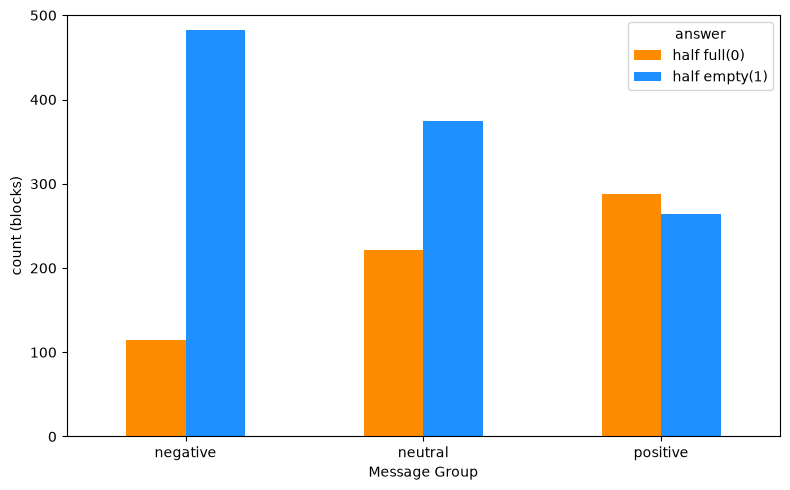

In [64]:
# 0/1 の列をそろえて、ラベルを付ける
counts = counts.reindex(columns=[0, 1], fill_value=0)
counts.columns = ["half full(0)", "half empty(1)"]

ax = counts.plot(kind="bar", figsize=(8, 5), rot=0, color=["#ff8c00", "#1e90ff"])
ax.set_xlabel("Message Group")
ax.set_ylabel("count (blocks)")
ax.legend(title="answer")
plt.ylim(0,500)
plt.tight_layout()
plt.show()

In [65]:
print(counts)

               half full(0)  half empty(1)
Message Group                             
negative              115.0          482.0
neutral               221.0          374.0
positive              288.0          264.0


#### フレーム選択の反応時間

In [66]:
df_unique = df.drop_duplicates(
    subset=["responseId", "Message Group", "frame_choice", "Page Submit_fc"]
)

participant_dist = pd.crosstab(
    df_unique["responseId"],
    df_unique["frame_choice"]
)

In [67]:
# 選択率
participant_rate = participant_dist.div(
    participant_dist.sum(axis=1), axis=0
)
participant_rate

frame_choice,0.0,1.0
responseId,,
R_41hDHe81EktidI7,0.15,0.85
R_43dc9zIe799ZkvO,1.00,0.00
R_43yGfPC8t2nxj5w,0.00,1.00
R_4556rIG7daK6Zep,0.00,1.00
R_45F4qpOliX2RsUs,0.45,0.55
...,...,...
R_9orFoDJ6zcmMMjD,0.45,0.55
R_9rwYifu6aRUz6A3,0.00,1.00
R_9tL50jGcwrw1PZq,0.00,1.00


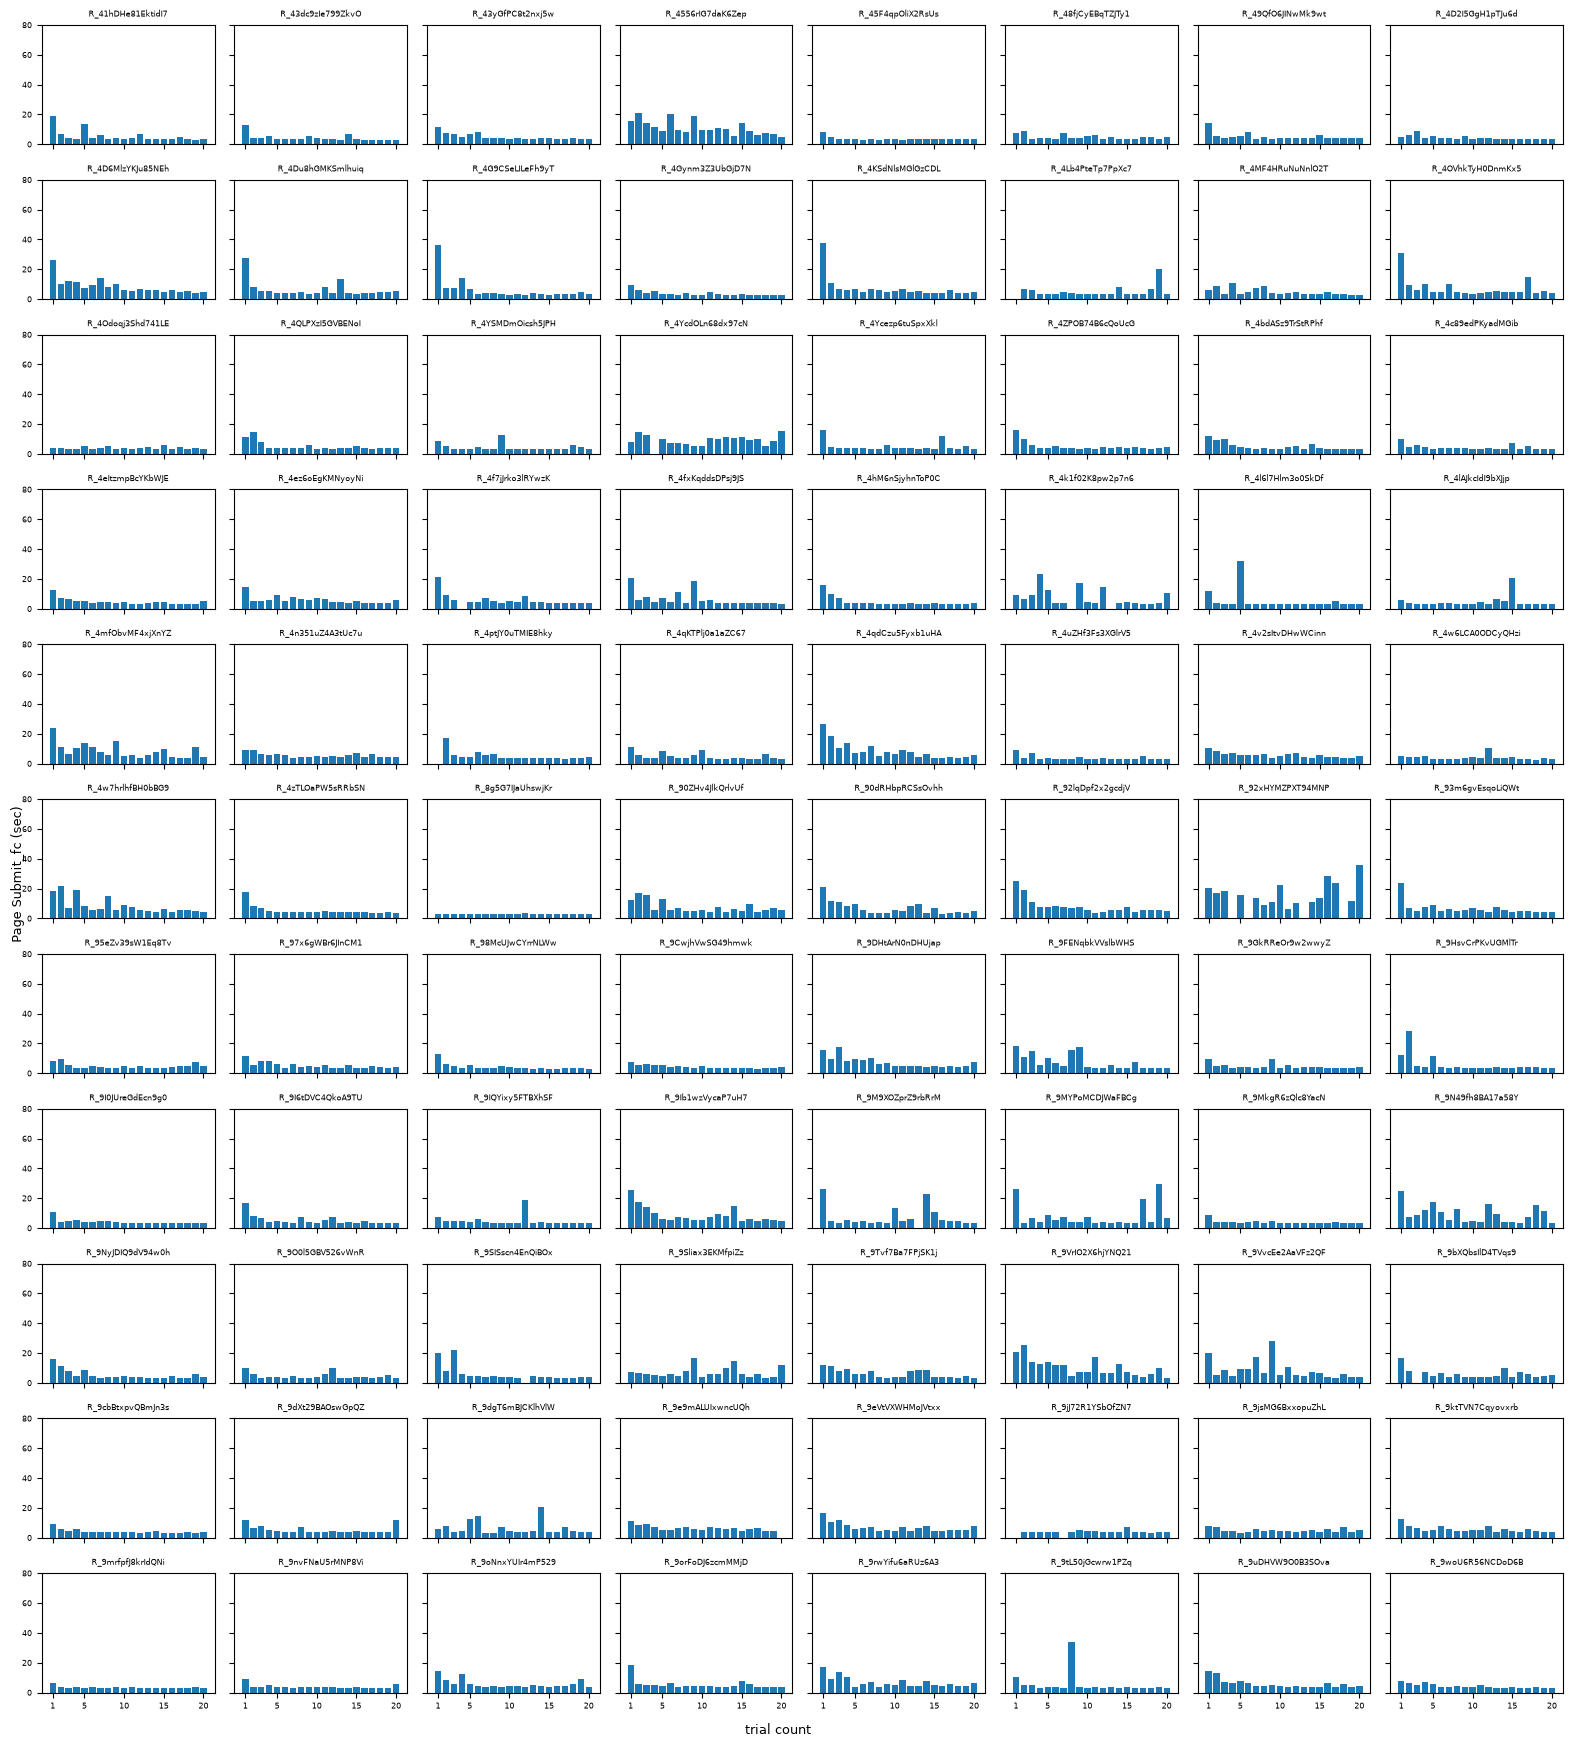

In [68]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ブロックごとに、各列の最初の非NaN値を取得(先頭行がNaNでも拾える)
df_fc = (
    df.sort_values(["responseId", "frame_block", "ref_subblock"])
      .groupby(["responseId", "frame_block"], as_index=False)[
          ["Page Submit_fc", "frame_choice", "Message Group"]
      ]
      .first()
)
df_fc["trial"] = df_fc["frame_block"] + 1

participants = list(df_fc.groupby("responseId"))

ncols = 8
nrows = math.ceil(len(participants) / ncols)
ymax = 80

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, nrows * 1.6),
    sharex=True, sharey=True,
    squeeze=False,
)
axes = axes.flatten()

for ax, (response_id, data) in zip(axes, participants):
    rt = data["Page Submit_fc"]
    y = rt.clip(upper=ymax)                              # 上限で切る(NaNはそのまま空白)
    colors = np.where(rt > ymax, "red", "#1f77b4")       # 上限超えは赤

    ax.bar(data["trial"], y, color=colors)
    ax.set_title(response_id, fontsize=6)
    ax.set_ylim(0, ymax)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.tick_params(labelsize=6)

# 余った枠を非表示
for ax in axes[len(participants):]:
    ax.axis("off")

fig.supxlabel("trial count", fontsize=9)
fig.supylabel("Page Submit_fc (sec)", fontsize=9)
plt.tight_layout()
plt.show()